In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [7]:
df=pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(42000, 785)

In [9]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
1458,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31447,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36770,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4345,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15998,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
import matplotlib.pyplot as plt

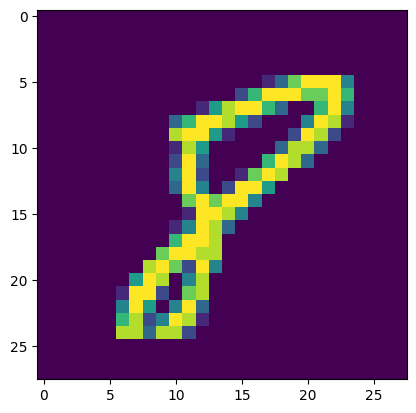

In [11]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [12]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train.shape

(33600, 784)

In [15]:
from sklearn.neighbors import KNeighborsClassifier 

In [16]:
knn=KNeighborsClassifier()

In [17]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [18]:
import time
start=time.time()
y_pred=knn.predict(x_test)
print(time.time()-start)

12.739245891571045


In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [21]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [22]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=None)

In [23]:
x_train=pca.fit_transform(x_train)
x_test=pca.transform(x_test)

In [24]:
x_train.shape

(33600, 784)

In [25]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
pca=PCA(n_components=350)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)
x_train_trf.shape

(33600, 350)

In [26]:
knn=KNeighborsClassifier()
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [27]:
y_pred=knn.predict(x_test_trf)

In [28]:
accuracy_score(y_pred,y_test)

0.9442857142857143

In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
pca=PCA(n_components=2)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [31]:
x_train_trf

array([[-2.71864632, -0.48996936],
       [-0.67698472, -6.75314583],
       [-3.03324505,  6.50900774],
       ...,
       [ 2.14886005,  0.78123326],
       [ 1.05955247,  0.94739786],
       [17.70258677,  1.96265279]])

In [32]:
x_train_trf

array([[-2.71864632, -0.48996936],
       [-0.67698472, -6.75314583],
       [-3.03324505,  6.50900774],
       ...,
       [ 2.14886005,  0.78123326],
       [ 1.05955247,  0.94739786],
       [17.70258677,  1.96265279]])

In [33]:
x_train_trf

array([[-2.71864632, -0.48996936],
       [-0.67698472, -6.75314583],
       [-3.03324505,  6.50900774],
       ...,
       [ 2.14886005,  0.78123326],
       [ 1.05955247,  0.94739786],
       [17.70258677,  1.96265279]])

In [34]:
x_train_trf

array([[-2.71864632, -0.48996936],
       [-0.67698472, -6.75314583],
       [-3.03324505,  6.50900774],
       ...,
       [ 2.14886005,  0.78123326],
       [ 1.05955247,  0.94739786],
       [17.70258677,  1.96265279]])

In [35]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=x_train_trf[:,0],
              y=x_train_trf[:,1],
              color=y_train_trf,
              color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
pca=PCA(n_components=3)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [37]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(x=x_train_trf[:,0],
              y=x_train_trf[:,1],
              z=x_train_trf[:,2],
              color=y_train_trf
              )
fig.show()

In [44]:
pca.explained_variance_

array([40.67111197, 29.170234  , 26.74459614])

In [45]:
pca.components_

array([[ 2.96801010e-18,  9.11046699e-19,  3.60514203e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-3.42793823e-17,  8.41184221e-18,  5.38545775e-18, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-8.18564328e-18,  4.10559513e-17,  1.42045833e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [46]:
pca.components_.shape

(3, 784)

In [48]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])